# Baseline and variant review — low-review risk classification

Target `is_low_review` (review score 1-2) at the survey trigger T = min(delivered date, estimated date).
Stakeholder: Olist CX / seller-quality team. Primary metric: **PR-AUC** (fixed before modelling).

Protocol (shared with the regression package)
* chronological windows with label maturity: train = purchased and label known before 2018-03-01 · validation = March 2018 · Apr-Jun maturation gap · test = Jul-Aug 2018
* family ladder A (logistic) → B (decision tree → random forest → CatBoost) → C (stacking)
* class weights, not resampling; threshold chosen on validation to maximise F1, then frozen
* RandomizedSearchCV on the training window with 3 expanding, label-matured folds (`split.matured_cv`)
* the test window is scored once, at the end, for every row of the table

Set `QUICK = True` for a dry run (4 search draws, small forests, full training window); the report numbers come from `QUICK = False`.

In [1]:
from pathlib import Path
import sys, warnings
_c = Path.cwd()
ROOT = next((p for p in [_c, *_c.parents, _c / "Phase 2" / "classification", _c / "classification"]
             if (p / "config" / "problem_spec.json").is_file() and (p / "src" / "paths.py").is_file()), None)
if ROOT is None:
    raise FileNotFoundError("Run from the repository root, Phase 2, or Phase 2/classification.")
sys.path.insert(0, str(ROOT / "src"))
import paths  # adds Phase 2/src (regression package) to sys.path as well
warnings.filterwarnings("ignore")

import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import clf_config as config, clf_features as features, clf_split as split, clf_pipelines as pipelines, clf_evaluate as evaluate
pd.set_option("display.width", 160); pd.set_option("display.max_columns", 40)
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False})
ACCENT, GREY, RED = "#2563eb", "#9ca3af", "#dc2626"
for d in (config.FIGURES_DIR, config.RESULTS_DIR, config.PROCESSED_DIR, config.MODELS_DIR): d.mkdir(parents=True, exist_ok=True)
print("package root:", ROOT)
import joblib, json, time
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import precision_recall_curve
from sklearn.calibration import calibration_curve

QUICK = False
N_ITER = 4 if QUICK else 30
PROBLEM = "p2"
SCORING = evaluate.SCORING[PROBLEM]       # average_precision

package root: c:\Users\wanglr\Downloads\scp5006\IT5006-Group9-Olist-Project\Phase 2\classification


## 1. Data

In [2]:
df = features.load_feature_table()
cohort = features.cohort(df, PROBLEM)
S = split.split_frame(cohort)
X_tr, y_tr = split.xy(S["train"], PROBLEM)
X_va, y_va = split.xy(S["validation"], PROBLEM)
X_te, y_te = split.xy(S["test"], PROBLEM)
CV = split.matured_cv(S["train"], PROBLEM)   # 3 expanding folds, label-matured
print({k: v.shape for k, v in S.items()}, "| features:", X_tr.shape[1])
display(split.window_summary(cohort, PROBLEM))
split.fold_summary(S["train"], PROBLEM)

{'train': (54372, 74), 'validation': (7125, 74), 'test': (12655, 74)} | features: 49


,orders,first purchase,last purchase,positive rate,delivered by T share
window,,,,,
train,54372,2016-09-04,2018-02-26,0.1366,0.917
validation,7125,2018-03-01,2018-03-31,0.2261,0.770
test,12655,2018-07-01,2018-08-29,0.1066,0.911
pending_label,3933,2018-01-06,2018-02-28,0.2914,0.699


,fit_rows,score_rows,score_from,score_to
fold,,,,
1,13395,12404,2017-07-01,2017-09-30
2,25366,17487,2017-10-01,2017-12-31
3,42250,9860,2018-01-01,2018-02-26


## 2. Baselines on the same rows

* majority class: predict nobody complains → PR-AUC equals the positive rate
* one-feature rule: "not delivered by the promised date ⇒ low review" (the strongest single Phase 1 finding)

In [3]:
results = evaluate.ResultsTable(PROBLEM)
thresholds, val_proba, test_proba, fitted = {}, {}, {}, {}

def record(name, p_tr, p_va, p_te, thr, extra=None):
    """One row: train / validation / test metrics at the frozen threshold."""
    row = {}
    for tag, y, p in (("train", y_tr, p_tr), ("val", y_va, p_va), ("test", y_te, p_te)):
        if p is None: continue
        m = evaluate.classification_metrics(y, p, thr)
        row.update({f"{tag}_{k}": v for k, v in m.items() if k != "threshold"})
    row["threshold"] = thr
    row.update(extra or {})
    results.add(name, **row)
    thresholds[name], val_proba[name], test_proba[name] = thr, p_va, p_te

# majority class: constant score
const = lambda y: np.full(len(y), y_tr.mean())
record("baseline_majority", const(y_tr), const(y_va), const(y_te), thr=1.0)
# rule: late at T (not delivered by the promised date) -> positive
rule = lambda X: (1 - X.delivered_by_T.values).astype(float)
record("baseline_rule_late", rule(X_tr), rule(X_va), rule(X_te), thr=0.5)
results.frame()[["val_pr_auc", "val_precision", "val_recall", "val_f1"]]

,val_pr_auc,val_precision,val_recall,val_f1
model,,,,
baseline_majority,0.226105,0.000000,0.000000,0.000000
baseline_rule_late,0.494721,0.639024,0.650528,0.644725


## 3. Family ladder with tuning

Each family starts from its simplest variant. Searches are scored on average precision over three expanding,
label-matured folds of the training window (fold k fits only on orders whose review was already written at
the fold cutoff). The threshold for each model is the F1-maximising
point on **validation**, frozen before the test window is touched.

In [4]:
models = pipelines.classification_models(PROBLEM)
if QUICK:  # small budgets for a dry run; report numbers come from QUICK = True
    models["B_rf"][1]["model__n_estimators"] = [100]
    models["B_catboost"][1]["model__iterations"] = [100, 200]
searches, best_params = {}, {}

for name, (pipe, space) in models.items():
    t0 = time.time()
    if space is None:
        est = pipe.fit(X_tr, y_tr); cv = {}
    else:
        rs = RandomizedSearchCV(pipe, space, n_iter=N_ITER,   # a 7-point list grid is exhausted, not sampled
                                cv=CV, scoring=SCORING, n_jobs=1,
                                random_state=config.RANDOM_STATE, refit=True)
        rs.fit(X_tr, y_tr); est = rs.best_estimator_; searches[name] = rs
        cv = evaluate.cv_summary(rs); best_params[name] = {k: (float(v) if isinstance(v, (np.floating, float)) else v) for k, v in rs.best_params_.items()}
    fitted[name] = est
    p_tr, p_va, p_te = (est.predict_proba(X)[:, 1] for X in (X_tr, X_va, X_te))
    thr = evaluate.best_threshold(y_va, p_va)
    record(name, p_tr, p_va, p_te, thr, extra=cv)
    print(f"{name:15s} val PR-AUC {evaluate.classification_metrics(y_va, p_va)['pr_auc']:.3f}  "
          f"cv {cv.get('cv_mean', float('nan')):.3f}±{cv.get('cv_sd', float('nan')):.3f}  thr {thr:.2f}  {time.time()-t0:.0f}s")

A_linear_base   val PR-AUC 0.600  cv nan±nan  thr 0.70  3s
A_linear_tuned  val PR-AUC 0.602  cv 0.460±0.050  thr 0.75  29s
B_tree_base     val PR-AUC 0.618  cv 0.433±0.053  thr 0.72  101s
B_rf            val PR-AUC 0.642  cv 0.463±0.056  thr 0.62  2323s
B_catboost      val PR-AUC 0.602  cv 0.461±0.050  thr 0.67  6370s


### CatBoost: iterations by early stopping on validation

The search treats `iterations` as a coarse hyperparameter; the final CatBoost refits the best configuration
with `od_wait = 50` on the validation window and replaces the searched model if validation PR-AUC improves.

In [5]:
cb_es = pipelines.fit_catboost_early_stopping(fitted["B_catboost"], X_tr, y_tr, X_va, y_va,
                                              max_iterations=400 if QUICK else 3000)
p_va_es = cb_es.predict_proba(X_va)[:, 1]
ap_es, ap_rs = (evaluate.classification_metrics(y_va, p)["pr_auc"] for p in (p_va_es, val_proba["B_catboost"]))
print(f"early-stopped iterations: {cb_es.best_iteration_}  val PR-AUC {ap_es:.4f} vs searched {ap_rs:.4f}")
if ap_es > ap_rs:
    fitted["B_catboost"] = cb_es
    p_tr, p_te = cb_es.predict_proba(X_tr)[:, 1], cb_es.predict_proba(X_te)[:, 1]
    results.rows = [r for r in results.rows if r["model"] != "B_catboost"]
    record("B_catboost", p_tr, p_va_es, p_te, evaluate.best_threshold(y_va, p_va_es),
           extra={**evaluate.cv_summary(searches["B_catboost"]), "best_iteration": cb_es.best_iteration_})

early-stopped iterations: 712  val PR-AUC 0.6119 vs searched 0.6022


## 4. Model selection on validation, then stacking

The best single model is the one with the highest validation PR-AUC. Stacking (Family C) is fitted on the
tuned A_linear, B_rf and B_catboost pipelines and is **retained only if** it beats the best single model
by at least 1% relative on validation PR-AUC. Ties within one CV standard deviation go to the simpler model.

In [6]:
tbl = results.frame()
ladder = [m for m in models]
best_single = tbl.loc[ladder, "val_pr_auc"].idxmax()
print("best single model on validation:", best_single, round(tbl.loc[best_single, "val_pr_auc"], 4))

t0 = time.time()
stack = pipelines.make_stacking(PROBLEM, fitted)
if QUICK: stack.set_params(B_rf__model__n_estimators=60, B_catboost__model__iterations=150)
stack.fit(X_tr, y_tr)
p_tr, p_va, p_te = (stack.predict_proba(X)[:, 1] for X in (X_tr, X_va, X_te))
record("C_stacking", p_tr, p_va, p_te, evaluate.best_threshold(y_va, p_va),
       extra={"meta_coef": json.dumps(dict(zip(["A_linear_tuned", "B_rf", "B_catboost"], np.round(stack.final_estimator_.coef_[0], 3).tolist())))})
fitted["C_stacking"] = stack
gain = tbl.loc[best_single, "val_pr_auc"]
ap_stack = evaluate.classification_metrics(y_va, p_va)["pr_auc"]
keep_stack = ap_stack >= 1.01 * gain
FINAL = "C_stacking" if keep_stack else best_single
print(f"stacking val PR-AUC {ap_stack:.4f} vs {gain:.4f} -> {'retained' if keep_stack else 'not retained'}; FINAL = {FINAL}  ({time.time()-t0:.0f}s)")

best single model on validation: B_rf 0.6419
stacking val PR-AUC 0.6321 vs 0.6419 -> not retained; FINAL = B_rf  (475s)


## 5. Results table (report Table 7)

Every model is scored on the test window once, at its frozen threshold. `cv_mean ± cv_sd` is the
training-window cross-validation estimate of PR-AUC for the chosen configuration over the three matured folds.

In [7]:
cols = ["cv_mean", "cv_sd", "val_pr_auc", "test_pr_auc", "test_roc_auc", "test_precision", "test_recall",
        "test_f1", "test_balanced_acc", "test_brier", "test_recall_top10", "test_accuracy", "threshold"]
table7 = results.save("model_comparison")[cols].round(3)
table7

,cv_mean,cv_sd,val_pr_auc,test_pr_auc,test_roc_auc,test_precision,test_recall,test_f1,test_balanced_acc,test_brier,test_recall_top10,test_accuracy,threshold
model,,,,,,,,,,,,,
baseline_majority,NaN,NaN,0.226,0.107,0.500,0.000,0.000,0.000,0.500,0.096,0.080,0.893,1.000
baseline_rule_late,NaN,NaN,0.495,0.200,0.633,0.392,0.327,0.357,0.633,0.126,0.335,0.874,0.500
A_linear_base,NaN,NaN,0.600,0.361,0.734,0.388,0.404,0.396,0.664,0.157,0.381,0.869,0.700
A_linear_tuned,0.460,0.050,0.602,0.358,0.735,0.399,0.402,0.400,0.665,0.159,0.380,0.872,0.753
B_tree_base,0.433,0.053,0.618,0.326,0.712,0.371,0.424,0.396,0.669,0.170,0.383,0.862,0.720
B_rf,0.463,0.056,0.642,0.356,0.731,0.373,0.421,0.396,0.668,0.157,0.373,0.863,0.623
B_catboost,0.461,0.050,0.612,0.358,0.731,0.399,0.396,0.397,0.662,0.166,0.374,0.872,0.720
C_stacking,NaN,NaN,0.632,0.368,0.735,0.399,0.400,0.399,0.664,0.086,0.371,0.872,0.368


In [8]:
# train vs validation gap = overfitting check
results.frame()[["train_pr_auc", "val_pr_auc", "test_pr_auc"]].round(3)

,train_pr_auc,val_pr_auc,test_pr_auc
model,,,
baseline_majority,0.137,0.226,0.107
baseline_rule_late,0.317,0.495,0.200
A_linear_base,0.485,0.600,0.361
A_linear_tuned,0.477,0.602,0.358
B_tree_base,0.505,0.618,0.326
B_rf,0.554,0.642,0.356
B_catboost,0.506,0.612,0.358
C_stacking,0.532,0.632,0.368


## 6. Figures (report Figure 3)

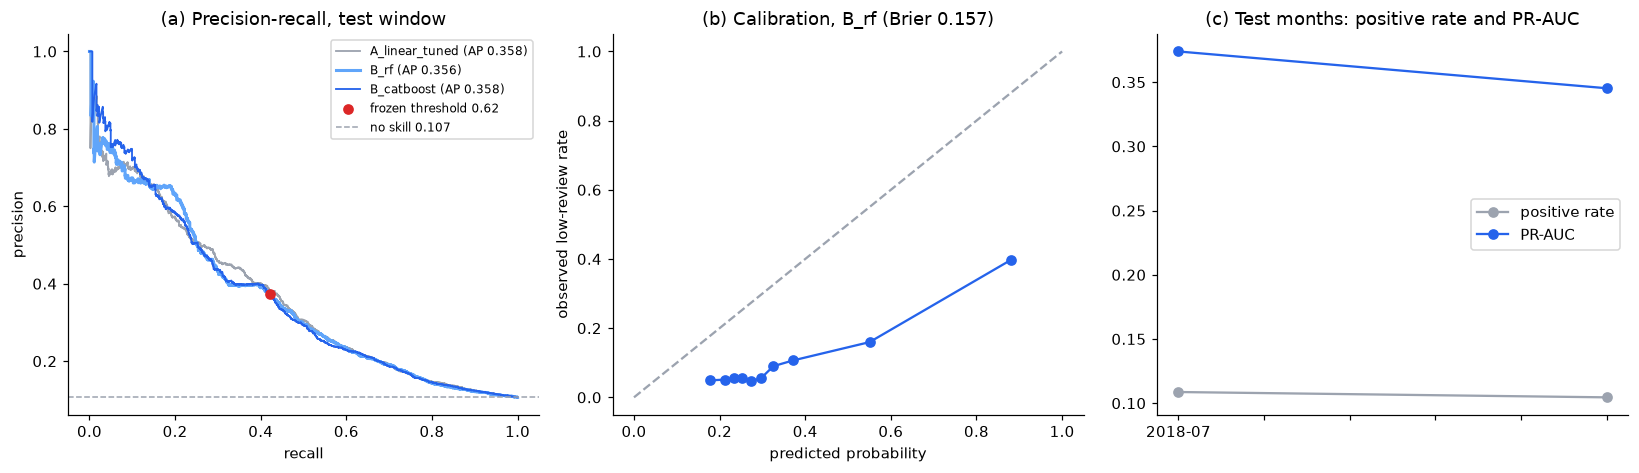

In [9]:
fig, ax = plt.subplots(1, 3, figsize=(15, 4.4))
# (a) PR curves on test for the family-best models
show = ["A_linear_tuned", "B_rf", "B_catboost"] + (["C_stacking"] if keep_stack else [])
palette = dict(zip(show, [GREY, "#60a5fa", ACCENT, "#1e3a8a"]))
for name in show:
    p, r, _ = precision_recall_curve(y_te, test_proba[name])
    ap = evaluate.classification_metrics(y_te, test_proba[name])["pr_auc"]
    ax[0].plot(r, p, color=palette[name], label=f"{name} (AP {ap:.3f})", lw=2 if name == FINAL else 1.2)
m = evaluate.classification_metrics(y_te, test_proba[FINAL], thresholds[FINAL])
ax[0].scatter([m["recall"]], [m["precision"]], color=RED, zorder=5, label=f"frozen threshold {thresholds[FINAL]:.2f}")
ax[0].axhline(y_te.mean(), ls="--", color=GREY, lw=1, label=f"no skill {y_te.mean():.3f}")
ax[0].set_xlabel("recall"); ax[0].set_ylabel("precision"); ax[0].set_title("(a) Precision-recall, test window"); ax[0].legend(fontsize=8)
# (b) calibration of the final model
frac, mean_pred = calibration_curve(y_te, test_proba[FINAL], n_bins=10, strategy="quantile")
ax[1].plot(mean_pred, frac, marker="o", color=ACCENT); ax[1].plot([0, 1], [0, 1], ls="--", color=GREY)
ax[1].set_xlabel("predicted probability"); ax[1].set_ylabel("observed low-review rate"); ax[1].set_title(f"(b) Calibration, {FINAL} (Brier {m['brier']:.3f})")
# (c) monthly drift in the test window
te = S["test"].assign(proba=test_proba[FINAL])
drift = te.groupby("purchase_month").apply(lambda g: pd.Series({"positive rate": g.is_low_review.mean(),
        "PR-AUC": evaluate.classification_metrics(g.is_low_review, g.proba)["pr_auc"]}))
drift.plot(ax=ax[2], marker="o", color=[GREY, ACCENT]); ax[2].set_title("(c) Test months: positive rate and PR-AUC"); ax[2].set_xlabel("")
plt.tight_layout(); fig.savefig(config.FIGURES_DIR / "02_pr_calibration_drift.png", bbox_inches="tight")

## 7. Interpretability (report Figure 4b, Section 6.4)

Permutation importance on the **validation** window, model-agnostic so families are comparable, plus the
logistic coefficients as a linear cross-check.

,feature,importance_mean,importance_sd
0,delivery_vs_seller_prior_at_T,0.042473,0.006893
1,carrier_transit_days_at_T,0.041628,0.006491
2,days_vs_promise_at_T,0.041468,0.006796
3,delivery_days_at_T,0.041223,0.007052
4,delivered_by_T,0.037600,0.006729
5,n_items,0.014790,0.000589
6,customer_zip2,0.008742,0.002428
7,promised_days,0.008548,0.001554
8,carrier_handover_days_at_T,0.007975,0.002167
9,carrier_shipped_by_T,0.007368,0.001513


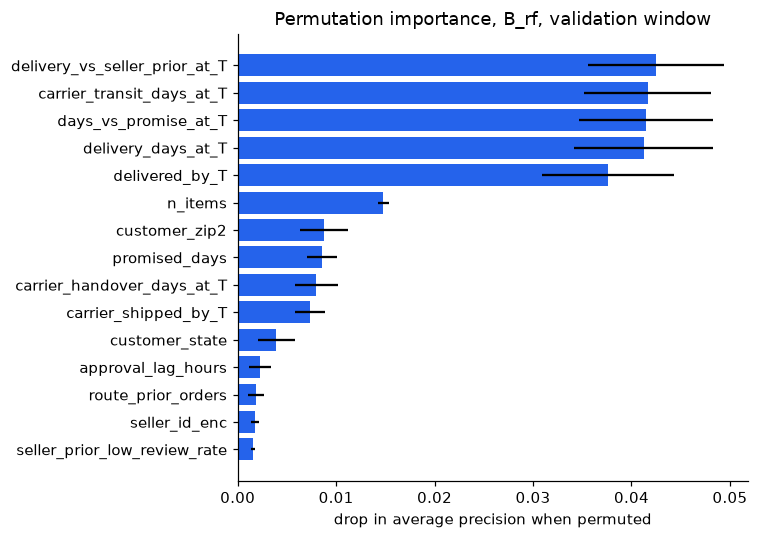

In [10]:
imp_model = best_single  # permutation importance on the best single model (a stacker's importances are not attributable)
imp = evaluate.permutation_table(fitted[imp_model], X_va, y_va, SCORING, n_repeats=3 if QUICK else 5, top=15)
imp.to_csv(config.RESULTS_DIR / "permutation_importance.csv", index=False)
fig, ax = plt.subplots(figsize=(7, 5))
ax.barh(imp.feature[::-1], imp.importance_mean[::-1], xerr=imp.importance_sd[::-1], color=ACCENT)
ax.set_xlabel("drop in average precision when permuted"); ax.set_title(f"Permutation importance, {imp_model}, validation window")
plt.tight_layout(); fig.savefig(config.FIGURES_DIR / "03_permutation_importance.png", bbox_inches="tight")
imp

In [11]:
# linear cross-check: standardised logistic coefficients
lin = fitted["A_linear_tuned"]
names = lin.named_steps["pre"].get_feature_names_out()
coef = pd.Series(lin.named_steps["model"].coef_[0], index=names).sort_values()
pd.concat([coef.head(8), coef.tail(8)]).round(3).to_frame("logistic coefficient (standardised)")

,logistic coefficient (standardised)
num__delivered_by_T,-0.151
low__customer_state_RN,-0.128
skew__max_distance_km,-0.116
num__carrier_transit_days_at_T,-0.111
low__seller_state_RS,-0.104
low__seller_state_MT,-0.091
low__customer_region_North,-0.090
low__customer_state_RS,-0.088
num__missingindicator_delivery_days_at_T,0.151
low__seller_state_DF,0.152


## 8. Ablation: how much does the delivery-as-of-T block add?

Refits the best single configuration without the `delivery_at_T` group. The PR-AUC drop quantifies the
Phase 1 finding that delivery performance drives satisfaction, and is the number to quote in Section 6.2.

In [12]:
from sklearn.base import clone
at_T = config.FEATURE_GROUPS["delivery_at_T"]
keep = [c for c in X_tr.columns if c not in at_T]
abl = clone(fitted[best_single])
pre = abl.named_steps["pre"]
# drop the at-T columns from every transformer's column list
pre.set_params(transformers=[(n, t, [c for c in cols if c not in at_T]) for n, t, cols in pre.transformers])
if best_single == "B_catboost":
    abl.set_params(model__cat_features=[c for c in abl.named_steps["model"].cat_features if c in keep])
abl.fit(X_tr[keep], y_tr)
ap_full = evaluate.classification_metrics(y_va, val_proba[best_single])["pr_auc"]
ap_abl = evaluate.classification_metrics(y_va, abl.predict_proba(X_va[keep])[:, 1])["pr_auc"]
print(f"{best_single}: validation PR-AUC with delivery-at-T {ap_full:.3f} -> without {ap_abl:.3f}")

B_rf: validation PR-AUC with delivery-at-T 0.642 -> without 0.342


## 9. Optional sensitivity: class weights vs SMOTE (Appendix Table A3)

Runs only if `imbalanced-learn` is installed. Two rows: logistic regression and random forest with SMOTE inside the
pipeline (so it is applied per fold, to training rows only), compared with their class-weighted versions above.

In [13]:
try:
    from imblearn.over_sampling import SMOTE
    from imblearn.pipeline import Pipeline as ImbPipeline
    from sklearn.linear_model import LogisticRegression
    from sklearn.ensemble import RandomForestClassifier
    rows = []
    for name, model in [("A_logistic_smote", LogisticRegression(max_iter=2000, random_state=config.RANDOM_STATE)),
                        ("B_rf_smote", RandomForestClassifier(n_estimators=100 if QUICK else 400, min_samples_leaf=20,
                                                               n_jobs=-1, random_state=config.RANDOM_STATE))]:
        kind = "linear" if name.startswith("A") else "tree"
        pipe = ImbPipeline([("pre", pipelines.make_preprocessor(kind, PROBLEM)),
                            ("smote", SMOTE(random_state=config.RANDOM_STATE)), ("model", model)]).fit(X_tr, y_tr)
        p_va, p_te = pipe.predict_proba(X_va)[:, 1], pipe.predict_proba(X_te)[:, 1]
        thr = evaluate.best_threshold(y_va, p_va)
        rows.append({"model": name, **{f"val_{k}": v for k, v in evaluate.classification_metrics(y_va, p_va, thr).items()},
                     **{f"test_{k}": v for k, v in evaluate.classification_metrics(y_te, p_te, thr).items()}})
    a3 = pd.DataFrame(rows).set_index("model"); a3.to_csv(config.RESULTS_DIR / "smote_sensitivity.csv")
    display(a3[["val_pr_auc", "test_pr_auc", "test_precision", "test_recall", "test_f1", "test_brier"]].round(3))
except ImportError:
    print("imbalanced-learn not installed - skip (pip install imbalanced-learn to run Appendix Table A3)")

,val_pr_auc,test_pr_auc,test_precision,test_recall,test_f1,test_brier
model,,,,,,
A_logistic_smote,0.598,0.359,0.398,0.385,0.392,0.147
B_rf_smote,0.628,0.355,0.397,0.400,0.399,0.101


## 10. Save for the report and Phase 3

* `outputs/tables/model_comparison.csv` – report Table 7
* `outputs/selected_models.json` – chosen configurations (Appendix Table A1), final model, frozen thresholds
* `models/final_pipeline.joblib` – the final pipeline for the Phase 3 app, with its frozen threshold

In [14]:
config.MODELS_DIR.mkdir(parents=True, exist_ok=True)
with open(config.ROOT / "outputs" / "selected_models.json", "w") as f:
    json.dump({"best_params": best_params, "final_model": FINAL, "thresholds": thresholds, "seed": config.RANDOM_STATE,
               "stacking_retained": bool(keep_stack), "quick_mode": QUICK, "test_scored": True,
               "features": list(X_tr.columns)}, f, indent=2, default=str)
joblib.dump({"pipeline": fitted[FINAL], "threshold": thresholds[FINAL], "features": list(X_tr.columns),
             "problem": PROBLEM, "model_name": FINAL}, config.MODELS_DIR / "final_pipeline.joblib")
# per-order predictions for independent verification (git-ignored, regenerated by this notebook)
(config.ROOT / "outputs" / "predictions").mkdir(parents=True, exist_ok=True)
for tag, frame, probas in (("validation", S["validation"], val_proba), ("test", S["test"], test_proba)):
    pd.DataFrame({"order_id": frame.order_id, "is_low_review": frame.is_low_review.astype(int), **probas}).to_csv(
        config.ROOT / "outputs" / "predictions" / f"{tag}_predictions.csv", index=False)
print("final model:", FINAL, "| threshold:", round(thresholds[FINAL], 3))
table7.loc[[FINAL]]

final model: B_rf | threshold: 0.623


,cv_mean,cv_sd,val_pr_auc,test_pr_auc,test_roc_auc,test_precision,test_recall,test_f1,test_balanced_acc,test_brier,test_recall_top10,test_accuracy,threshold
model,,,,,,,,,,,,,
B_rf,0.463,0.056,0.642,0.356,0.731,0.373,0.421,0.396,0.668,0.157,0.373,0.863,0.623
